<a href="https://colab.research.google.com/github/Adrilopes/ml-flight-delay-prediction/blob/main/flight_delay_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

># ✈️ Flight Delay Prediction with Machine Learning

In this project, we build a **machine learning model to predict flight delays**.

The goal is to train a model capable of identifying whether a flight is likely to be delayed based on historical data.

The predictions generated by the model can later be used as input for **optimization processes**, helping airports and airlines improve operational efficiency.

> ## 🤖 Project Goal

Build a machine learning model that can:

- Learn patterns from historical flight data
- Predict potential flight delays
- Support decision-making and operational optimization

> ## 🧠 Machine Learning Approach

The project follows the typical machine learning workflow:

1. Data exploration
2. Data preprocessing
3. Train-test split
4. Model training
5. Model evaluation
6. Performance analysis

The final model will be evaluated using **accuracy and performance metrics**.

---

📚 This notebook is part of my learning journey in **Machine Learning and Data Science**.

## 1. Exploratory Data Analysis (EDA)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

dados = pd.read_csv('/content/drive/MyDrive/flights.csv')
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [3]:
dados.tail()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
71170,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,364,2022,True,25.677277
71171,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,364,2022,True,52.624348
71172,7,MM,Boeing 787,schengen,TZF,8.564949,13.564949,364,2022,True,56.167080
71173,5,BZ,Airbus A320,schengen,ZQO,9.344097,12.344097,364,2022,True,56.758844
71174,29,BZ,Boeing 737,schengen,ZQO,8.591208,11.591208,364,2022,True,41.401648


In [4]:
dados.shape

(71175, 11)

In [5]:
dados.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [6]:
dados.describe(include='object')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [7]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [8]:
dados.isnull().sum()

,0
flight_id,0
airline,0
aircraft_type,0
schengen,0
origin,0
arrival_time,0
departure_time,0
day,0
year,0
is_holiday,0


### 1.1 Data Visualization

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
average_delay = dados.groupby('airline')['delay'].mean().reset_index()
average_delay

,airline,delay
0,BZ,3.077595
1,MM,40.498007
2,YE,25.772248


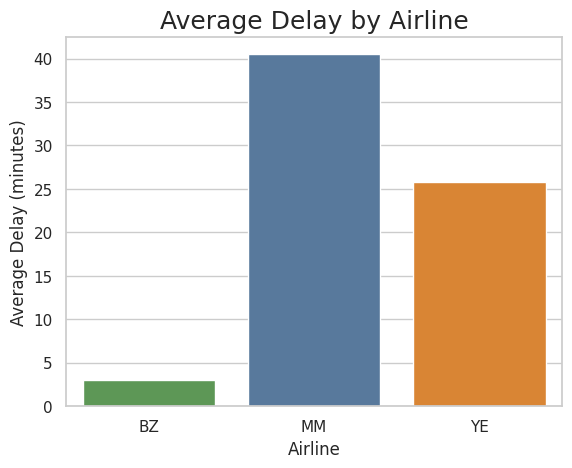

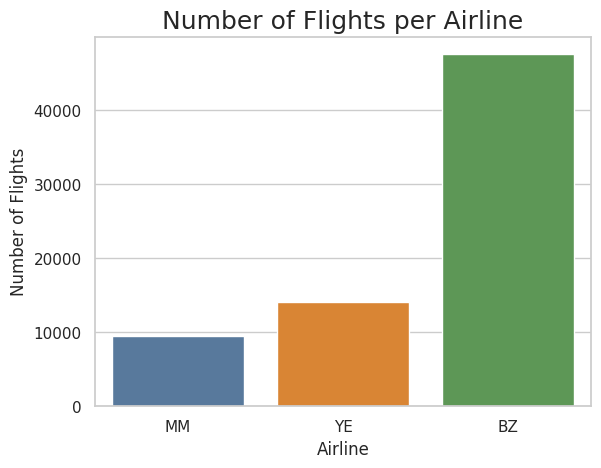

In [11]:
sns.set_theme(style="whitegrid")

palette = {
    "MM": "#4C78A8",
    "YE": "#F58518",
    "BZ": "#54A24B"
}

sns.barplot(x='airline', y='delay', hue='airline', data=average_delay, palette=palette, legend=False)

plt.title('Average Delay by Airline', fontsize=18)
plt.xlabel('Airline')
plt.ylabel('Average Delay (minutes)')
plt.show()

sns.countplot(data=dados, x='airline', hue='airline', palette=palette, legend=False)

plt.title('Number of Flights per Airline', fontsize=18)
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.show()

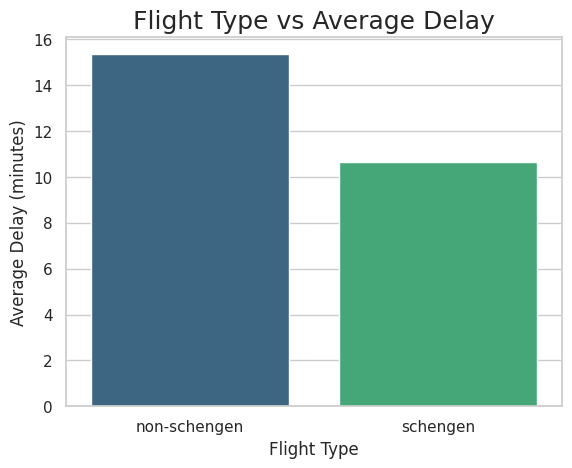

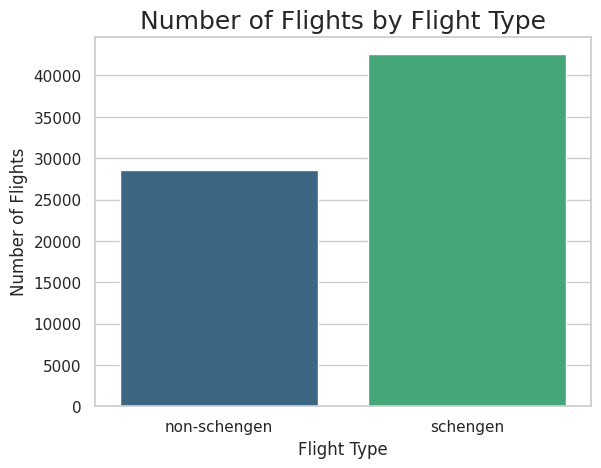

In [12]:
average_delay = dados.groupby('schengen')['delay'].mean().reset_index()

sns.barplot(
    x='schengen',
    y='delay',
    data=average_delay,
    hue='schengen',
    palette='viridis',
    legend=False
)

plt.title('Flight Type vs Average Delay', fontsize=18)
plt.xlabel('Flight Type')
plt.ylabel('Average Delay (minutes)')
plt.show()


sns.countplot(
    data=dados,
    x='schengen',
    hue='schengen',
    palette='viridis',
    legend=False
)

plt.title('Number of Flights by Flight Type', fontsize=18)
plt.xlabel('Flight Type')
plt.ylabel('Number of Flights')
plt.show()

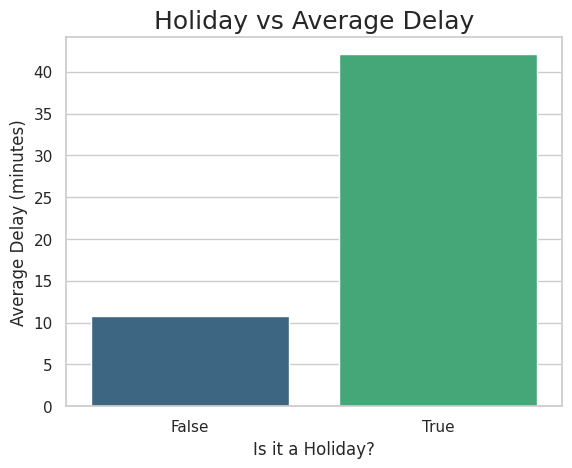

In [13]:
average_delay = dados.groupby('is_holiday')['delay'].mean().reset_index()

sns.barplot(
    x='is_holiday',
    y='delay',
    data=average_delay,
    hue='is_holiday',
    palette='viridis',
    legend=False
)

plt.title('Holiday vs Average Delay', fontsize=18)
plt.xlabel('Is it a Holiday?')
plt.ylabel('Average Delay (minutes)')
plt.show()

In [14]:
order = dados['aircraft_type'].value_counts().index
order

Index(['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175',
       'Boeing 737', 'Boeing 777'],
      dtype='object', name='aircraft_type')

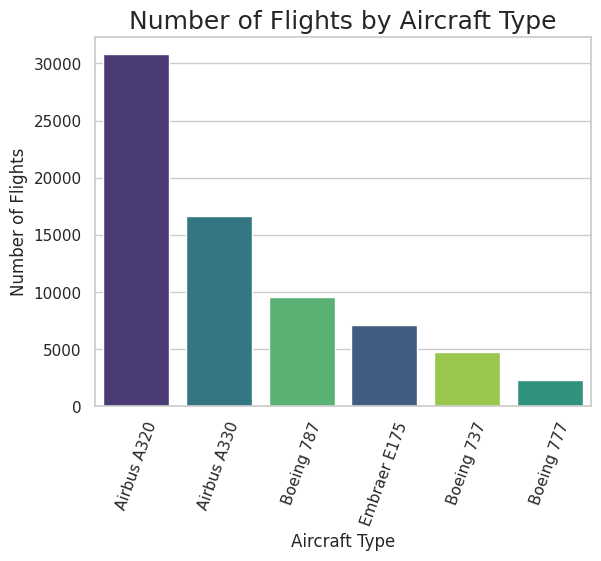

In [15]:
order = dados['aircraft_type'].value_counts().index

sns.countplot(
    data=dados,
    x='aircraft_type',
    hue='aircraft_type',
    order=order,
    palette='viridis'
)

plt.title('Number of Flights by Aircraft Type', fontsize=18)
plt.xticks(rotation=70)
plt.xlabel('Aircraft Type')
plt.ylabel('Number of Flights')

plt.show()

## 1.2 Data Distribution Analysis

In [16]:
#the Freedman–Diaconis rule
import numpy as np

def calcular_largura_bin(df, coluna):
    Q75, Q25 = np.percentile(df[coluna], [75 ,25])
    IQR = Q75 - Q25
    largura_bin = 2 * IQR * np.power(len(df[coluna]), -1/3)
    return largura_bin

<Axes: xlabel='arrival_time', ylabel='Count'>

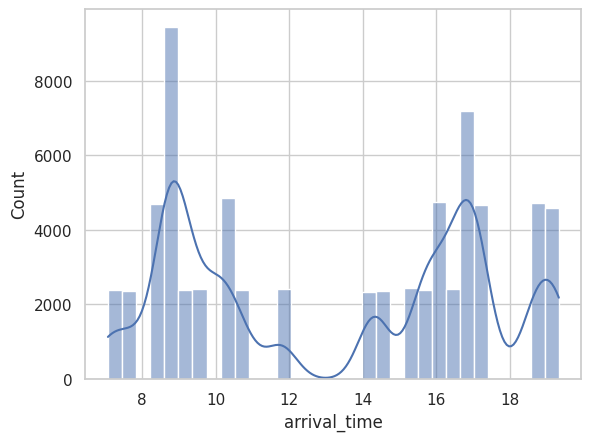

In [17]:
largura_bin_at = calcular_largura_bin(dados, 'arrival_time')

sns.histplot(data=dados, x='arrival_time', kde=True, binwidth=largura_bin_at)


<Axes: xlabel='departure_time', ylabel='Count'>

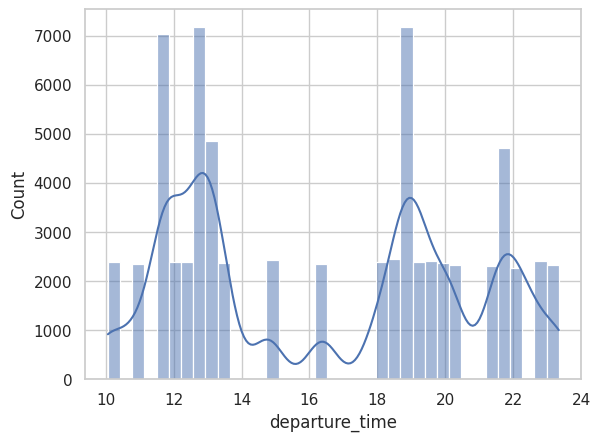

In [18]:
largura_bin_dt = calcular_largura_bin(dados, 'departure_time')

sns.histplot(data=dados, x='departure_time', kde=True, binwidth=largura_bin_dt)

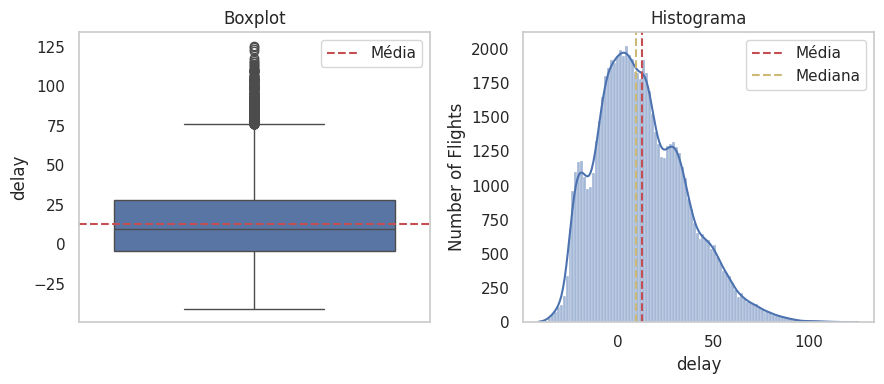

In [19]:
mean_delay = dados['delay'].mean()
median_delay = dados['delay'].median()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

sns.boxplot(data=dados, y='delay', ax=axes[0])
axes[0].set_title('Boxplot')
axes[0].grid(False)

axes[0].axhline(y=mean_delay, color='r', linestyle='--', label='Média')
axes[0].legend()

largura_bin_delay = calcular_largura_bin(dados, 'delay')
sns.histplot(data=dados, x='delay', ax=axes[1], kde=True, binwidth=largura_bin_delay)
plt.ylabel('Number of Flights')
plt.grid(False)
axes[1].set_title('Histograma')

axes[1].axvline(x=mean_delay, color='r', linestyle='--', label='Média')
axes[1].axvline(x=median_delay, color='y', linestyle='--', label='Mediana')
axes[1].legend()

plt.tight_layout()
plt.show()


> ### 📊  Insights
> The boxplot shows a well-behaved distribution. Although there are a few points above the upper limit, they do not distort the data and are likely occasional outliers. The distribution is slightly right-skewed, which is expected for this type of variable.

> The mean is close to the median, indicating a stable distribution and good data quality. Therefore, no preprocessing or treatment is required for the target variable.

## 2. Feature engineering

> The date information will be used to create new features, such as the day of the week or whether the flight occurs on a weekend, helping improve flight analysis.

In [20]:
dados['date'] = pd.to_datetime(dados['year'].astype(str) + '-' + (dados['day'] + 1).astype(str), format='%Y-%j')
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01


In [21]:
dados['is_weekend'] = dados['date'].dt.weekday.isin([5, 6])

In [22]:
dados['day_name'] = dados['date'].dt.day_name()

In [23]:
dados.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01,False,Friday
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01,False,Friday
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305,2010-01-01,False,Friday
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491,2010-01-01,False,Friday
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271,2010-01-01,False,Friday


## 2.2 Feature encoding

In [24]:
dados.nunique()

,0
flight_id,30
airline,3
aircraft_type,6
schengen,2
origin,10
arrival_time,30
departure_time,30
day,365
year,13
is_holiday,2


In [25]:
dados['schengen'].unique()

array(['non-schengen', 'schengen'], dtype=object)

In [26]:
dados['is_holiday'].unique()

array([False,  True])

In [27]:
dados['schengen'] = dados['schengen'].replace({'non-schengen': 0, 'schengen': 1}).astype(int)
dados['is_holiday'] = dados['is_holiday'].replace({False: 0, True: 1}).astype(int)
dados['is_weekend'] = dados['is_weekend'].replace({False: 0, True: 1}).astype(int)
dados.head()


/tmp/ipykernel_1495/2408173340.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['schengen'] = dados['schengen'].replace({'non-schengen': 0, 'schengen': 1}).astype(int)
/tmp/ipykernel_1495/2408173340.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dados['is_holiday'] = dados['is_holiday'].replace({False: 0, True: 1}).astype(int)
/tmp/ipykernel_1495/2408173340.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
0,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,Friday
1,10,YE,Airbus A320,0,TCY,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,Friday
2,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,Friday
3,28,BZ,Airbus A330,0,EMM,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,Friday
4,15,BZ,Airbus A330,0,FJB,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,Friday


In [28]:
variaveis_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']

In [29]:
#get_dummies: One-hot encoding to convert categorical variables into numeric features
df_encoded = pd.get_dummies(data=dados, columns=variaveis_categoricas, dtype=int)
df_encoded.head()

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
1,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0,...,1,0,0,1,0,0,0,0,0,0
2,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0,...,0,1,0,1,0,0,0,0,0,0
3,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0
4,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0,...,0,0,0,1,0,0,0,0,0,0


## 2.3 Data Cleaning

In [30]:
##corr(): Correlation matrix to analyze relationships between variables
df_encoded[['arrival_time', 'departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [31]:
df_clean = df_encoded.drop(["flight_id", "departure_time", "day", "year", "date"], axis=1)
df_clean.head()

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,0,8.885071,0,70.205981,0,0,1,0,1,0,...,1,0,0,1,0,0,0,0,0,0
1,0,8.939996,0,38.484609,0,0,0,1,1,0,...,1,0,0,1,0,0,0,0,0,0
2,1,18.635384,0,2.388305,0,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,15.967963,0,19.138491,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,16.571894,0,15.016271,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


## 3. Model Selection & Validation

> Building baseline regression models using **DummyRegressor** from Scikit-Learn

This model is used only for comparison and should not be used as the final model.

In [32]:
X = df_clean.drop(['delay'], axis=1)
y = df_clean['delay']

In [33]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [34]:
from sklearn.dummy import DummyRegressor

model_dummy = DummyRegressor()
model_dummy.fit(X_train, y_train)

DummyRegressor()

In [35]:
y_pred_dummy = model_dummy.predict(X_test)
y_pred_dummy

array([12.52857512, 12.52857512, 12.52857512, ..., 12.52857512,
       12.52857512, 12.52857512])

In [36]:
# Evaluate how well the model fits the data using evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_regression_metrics(y_test, y_pred):

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    metricas = {
        'Raiz do Erro Quadrático Médio': round(rmse, 4),
        'Erro Absoluto Médio': round(mae, 4),
        'R2 Score': round(r2, 4)
    }

    return metricas

In [37]:
# Updated scikit-learn because older versions do not support the 'squared=False' parameter
# used to compute RMSE directly from mean_squared_error
!pip install scikit-learn==1.3.2

In [38]:
calculate_regression_metrics(y_test, y_pred_dummy)

{'Raiz do Erro Quadrático Médio': 23.2241,
 'Erro Absoluto Médio': 18.6127,
 'R2 Score': -0.0}

In [39]:
# Testing different DummyRegressor strategies and comparing their performance
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def calcular_metricas_regressao(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2 Score": round(r2, 2)}

estrategias = ["mean", "median", ("quantile", 0.25), ("constant", 10.0)]
resultados = {}

for estrategia in estrategias:
    if isinstance(estrategia, tuple):
        tipo, valor = estrategia
        if tipo == "quantile":
            model = DummyRegressor(strategy=tipo, quantile=valor)
        else:
            model = DummyRegressor(strategy=tipo, constant=valor)
    else:
        model = DummyRegressor(strategy=estrategia)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    resultados[str(estrategia)] = calcular_metricas_regressao(y_test, y_pred)


In [40]:
df_resultados = pd.DataFrame(resultados).T
df_resultados

,RMSE,MAE,R2 Score
mean,23.22,18.61,-0.00
median,23.40,18.49,-0.02
"('quantile', 0.25)",28.79,22.04,-0.54
"('constant', 10.0)",23.37,18.49,-0.01


## 3.1 Random Forest Regressor Training and Evaluation
Random Forest Regressor is a regression model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [41]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

calculate_regression_metrics(y_test, y_pred_rf)

{'Raiz do Erro Quadrático Médio': 13.7301,
 'Erro Absoluto Médio': 11.0138,
 'R2 Score': 0.6505}

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


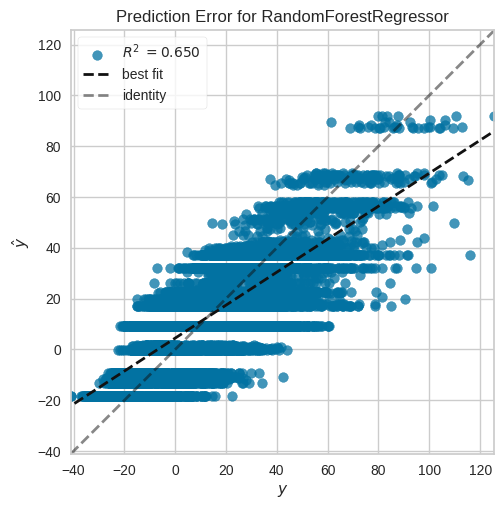

In [42]:
from yellowbrick.regressor import prediction_error

visualizer = prediction_error(model_rf, X_train, y_train, X_test, y_test)

> ### 📊  Insights
> The ideal scenario is when all points lie on the identity line (the diagonal line), meaning that the predicted values perfectly match the actual values.

> In our case, the points are not exactly on this line, but they are reasonably close to it. This indicates that the model is able to capture the general pattern of the data.

> With an R² score of 0.65, the predictions show some variability but still follow the trend of the identity line. If the points were highly scattered, it would indicate poor model performance. Overall, the model provides a reasonably good fit to the data.

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


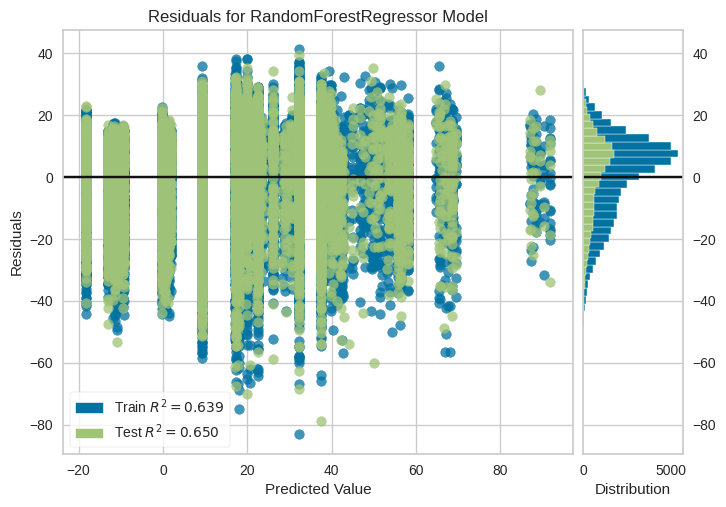

In [43]:
from yellowbrick.regressor import residuals_plot

viz = residuals_plot(model_rf, X_train, y_train, X_test, y_test)

> ### 📊 Residual Analysis

>In the residual plot (left), the points are randomly distributed around the zero line, which indicates that the model does not show strong systematic errors. A random dispersion of residuals around zero generally suggests that the model is capturing the underlying patterns of the data.

>In the residual histogram (right), most residuals are concentrated around zero and show an approximately normal distribution. This means that the prediction errors are relatively small and balanced, indicating a reasonable model fit.

>Although the model performs better than the baseline and shows good graphical and metric results, it is important to validate it properly to avoid bias caused by the specific train-test split. Therefore, the next step is model validation.

## 3.2 Cross-Validation

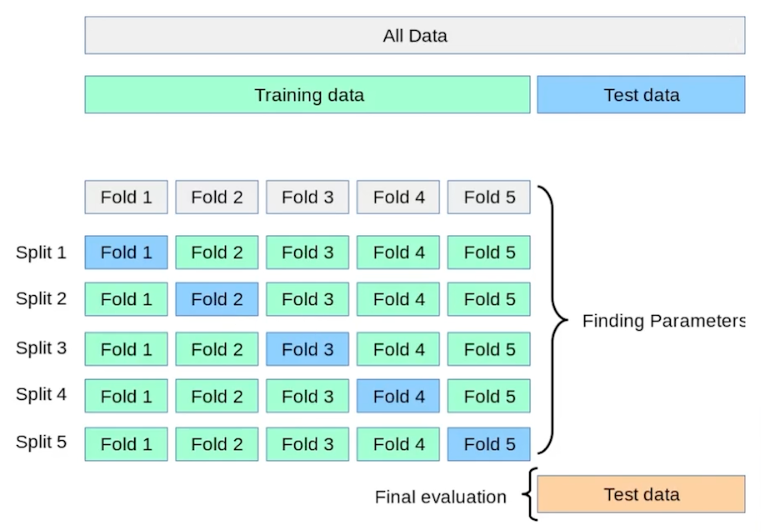

In [44]:
from sklearn.model_selection import KFold, cross_validate

scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# Shuffle the data to avoid bias caused by ordered or sequential patterns
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(model_rf, X_train, y_train, cv=cv, scoring=scoring)
cv_results

{'fit_time': array([10.70959473,  5.5709374 ,  4.14175415,  3.99527526,  3.00796652]),
 'score_time': array([0.19530344, 0.05105662, 0.0726769 , 0.05287647, 0.04906487]),
 'test_mae': array([-11.07421449, -11.30328674, -11.05630068, -11.14454886,
        -11.17423931]),
 'test_rmse': array([-13.76668658, -14.04881475, -13.79310018, -13.87672957,
        -13.9303929 ]),
 'test_r2': array([0.64679676, 0.62433581, 0.64536956, 0.64090813, 0.63477298])}

In [45]:
for metric in scoring.keys():
    scores = cv_results[f'test_{metric}']
    mean_score = "{:.3f}".format(scores.mean())
    std_score = "{:.3f}".format(scores.std())

    print(f"{metric.upper()} Scores: {[f' {val:.3f}' for val in scores]}")
    print(f"{metric.upper()} Média: {mean_score}, Std: {std_score}")
    print('----------------------------------------------------------------------------------')

MAE Scores: [' -11.074', ' -11.303', ' -11.056', ' -11.145', ' -11.174']
MAE Média: -11.151, Std: 0.088
----------------------------------------------------------------------------------
RMSE Scores: [' -13.767', ' -14.049', ' -13.793', ' -13.877', ' -13.930']
RMSE Média: -13.883, Std: 0.101
----------------------------------------------------------------------------------
R2 Scores: [' 0.647', ' 0.624', ' 0.645', ' 0.641', ' 0.635']
R2 Média: 0.638, Std: 0.008
----------------------------------------------------------------------------------


> ### 📊  Insights

> The cross-validation results are very close to the metrics obtained in the previous train-test split (MAE ≈ 11.5, RMSE ≈ 13.9, R² ≈ 0.64). This indicates that the model performance is consistent and not dependent on a specific data split.

> Additionally, the low standard deviation across the folds suggests that the model is stable. Overall, the results confirm that the model fits the data reasonably well, although further improvements can still be explored.

## 4. Hyperparameter Tuning

Retraining the model with the most important features to reduce complexity while preserving performance...

[Documentation](https://www.scikit-yb.org/en/latest/api/model_selection/importances.html)

## 4.1 Selecting the Most Important Features

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


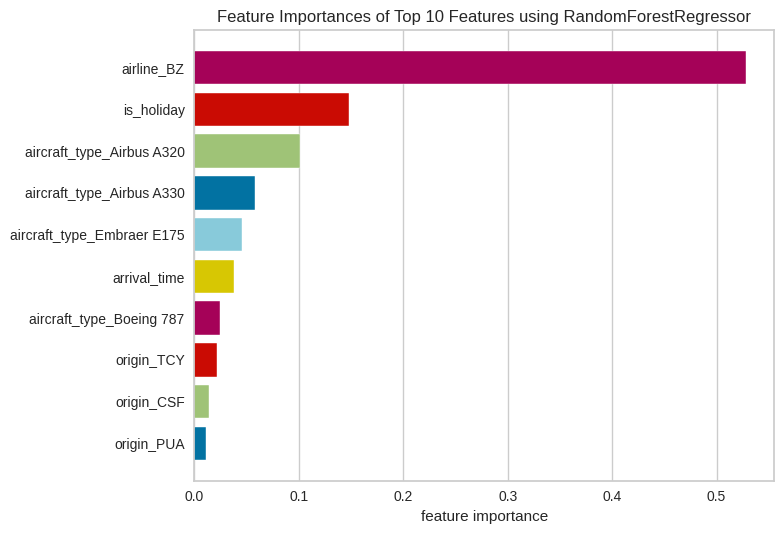

<Axes: title={'center': 'Feature Importances of Top 10 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [49]:
# Visualizing feature importance to identify which variables have the greatest impact on the model
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(model_rf, relative=False, topn=10) # Top 10 most important features
viz.fit(X_train, y_train)
viz.show()

In [52]:
importances = model_rf.feature_importances_
feature_importances = pd.DataFrame({'Features': X.columns, 'Importances': importances}).sort_values('Importances', ascending=False)
feature_importances

,Features,Importances
4,airline_BZ,0.528604
2,is_holiday,0.147833
7,aircraft_type_Airbus A320,0.100719
8,aircraft_type_Airbus A330,0.058221
12,aircraft_type_Embraer E175,0.045619
1,arrival_time,0.037614
11,aircraft_type_Boeing 787,0.024663
20,origin_TCY,0.022120
15,origin_CSF,0.013979
19,origin_PUA,0.011385


In [55]:
results_df = pd.DataFrame(index=['RMSE', 'MAE', 'R2'])

model_selected_features = RandomForestRegressor(random_state=42, max_depth=5)

for count in range(10, 16):

    selected_features = feature_importances['Features'].values[:count]

    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    model_selected_features.fit(X_train_selected, y_train)

    y_pred = model_selected_features.predict(X_test_selected)

    metricas = calcular_metricas_regressao(y_test, y_pred)

    results_df[count] = list(metricas.values())

results_df

,10,11,12,13,14,15
RMSE,13.74,13.74,13.73,13.73,13.73,13.73
MAE,11.03,11.03,11.02,11.02,11.02,11.02
R2,0.65,0.65,0.65,0.65,0.65,0.65


In [57]:
selected_features = feature_importances['Features'].values[:13]
X_selected_features = X[selected_features]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_selected_features, y, random_state=42)

## 4.2 Hyperparameter Tuning with GridSearchCV
[Documentation - Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)

[Documentation - GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

In [61]:
param_grid = {
'max_depth': [5, 10, 15],
'min_samples_leaf': [1, 2, 3],
'min_samples_split': [2, 4, 6],
'n_estimators': [100, 150, 200]
}

In [62]:
from sklearn.model_selection import GridSearchCV

In [64]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=param_grid,
             scoring='r2', cv=cv)

model_grid.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6],
                         'n_estimators': [100, 150, 200]},
             scoring='r2')

In [65]:
model_grid.best_params_

{'max_depth': 10,
 'min_samples_leaf': 3,
 'min_samples_split': 2,
 'n_estimators': 200}

In [66]:
y_pred_model_grid = model_grid.predict(X_test)

metricas_model_grid = calcular_metricas_regressao(y_test, y_pred_model_grid)
metricas_model_grid

{'RMSE': 13.23, 'MAE': 10.63, 'R2 Score': 0.68}

In [68]:
results_df['model_grid'] = list(metricas_model_grid.values())
results_df

,10,11,12,13,14,15,model_grid
RMSE,13.74,13.74,13.73,13.73,13.73,13.73,13.23
MAE,11.03,11.03,11.02,11.02,11.02,11.02,10.63
R2,0.65,0.65,0.65,0.65,0.65,0.65,0.68


## 4.3 Saving the Model

In [69]:
import pickle

In [70]:
try:
    with open('model_prod.pkl', 'wb') as file:
       pickle.dump(model_grid.best_estimator_, file)
    print('Model saved successfully!')
except Exception as e:
    print(f'Error saving model: {e}')

Model saved successfully!


## 5. Loading the Model and Making Predictions

To simulate a real-world scenario, we load the saved model and perform a prediction using a new flight sample.  
The following values represent the features of the new observation used for the prediction:

- **schengen:** 0  
- **arrival_time:** 10.8941  
- **is_holiday:** 0  
- **is_weekend:** 0  
- **airline_BZ:** 0  
- **airline_MM:** 0  
- **airline_YE:** 1  
- **aircraft_type_Airbus A320:** 1  
- **aircraft_type_Airbus A330:** 0  
- **aircraft_type_Boeing 737:** 0  
- **aircraft_type_Boeing 777:** 0  
- **aircraft_type_Boeing 787:** 0  
- **aircraft_type_Embraer E175:** 0  

These values are passed to the trained model to generate a delay prediction for the given flight scenario.


In [83]:
# Load the saved model
with open('model_prod.pkl', 'rb') as file:
    model_loaded = pickle.load(file)

# Check which feature names the saved model expects
expected_columns = model_loaded.feature_names_in_

# Create a new sample with the exact same feature names used during training
df_nova_amostra = pd.DataFrame(0.0, index=[0], columns=expected_columns)

# Fill only the known values, if those columns exist in the saved model
valores = {
    'schengen': 0,
    'arrival_time': 10.8941,
    'is_holiday': 0,
    'is_weekend': 0,
    'airline_BZ': 0,
    'airline_MM': 0,
    'airline_YE': 1,
    'aircraft_type_Airbus A320': 1,
    'aircraft_type_Airbus A330': 0,
    'aircraft_type_Boeing 737': 0,
    'aircraft_type_Boeing 777': 0,
    'aircraft_type_Boeing 787': 0,
    'aircraft_type_Embraer E175': 0
}

for coluna, valor in valores.items():
    if coluna in df_nova_amostra.columns:
        df_nova_amostra.loc[0, coluna] = valor

# Make prediction
previsao = model_loaded.predict(df_nova_amostra)

print("Predicted delay:", previsao[0])

Predicted delay: 36.70448664207053


> The model predicts an estimated delay of approximately **36.7 minutes** for the simulated flight scenario.  
> This demonstrates how the trained model can be used to generate predictions for new flight observations.

___

# 📊 Conclusion

In this project, we built a machine learning model capable of predicting flight delays. By anticipating potential delays, the model can support airport operational planning and decision-making.

Integrating this predictive information into airport processes can improve operational efficiency and contribute to reductions in both time and operational costs.

# ✈️ Future Work

Future improvements may include exploring additional machine learning models, refining feature engineering techniques, and integrating real-time flight data to further improve prediction performance.